CT-583: Tools and Techniques for Data Science
Classification with Comprehensive Analysis
UCI Adult Census Income Dataset

Objective: Predict whether an individual earns more than $50K/year.

| Item | Detail |
|------|--------|
| Dataset | UCI Adult Census Income (OpenML) |
| Task | Binary Classification |
| Models | Logistic Regression, Random Forest, XGBoost |
| Fairness | Gender and Race |


## 1. Imports and Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve,
                              ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
RANDOM_STATE = 42
print("All libraries imported successfully.")
print(f"NumPy {np.__version__} | Pandas {pd.__version__}")

All libraries imported successfully.
NumPy 2.0.2 | Pandas 2.2.2


## 2. Data Loading

We fetch the UCI Adult dataset directly from OpenML (version 2).
It contains approximately 48,000 records with 14 demographic and employment features.

In [2]:
print("Fetching UCI Adult dataset from OpenML...")
adult = fetch_openml('adult', version=2, as_frame=True)
X_raw = adult.data.copy()
y_raw = adult.target.copy()
print(f"Dataset loaded!")
print(f"Shape      : {X_raw.shape}")
print(f"Features   : {list(X_raw.columns)}")
print(f"Target     : {y_raw.unique().tolist()}")
print(f"Class dist :")
print(y_raw.value_counts(normalize=True).round(3))

Fetching UCI Adult dataset from OpenML...
Dataset loaded!
Shape      : (48842, 14)
Features   : ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']
Target     : ['<=50K', '>50K']
Class dist :
class
<=50K    0.761
>50K     0.239
Name: proportion, dtype: float64


In [3]:
X_raw.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States


In [4]:
missing = X_raw.isnull().sum()
missing_pct = (missing / len(X_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print("Columns with missing values:")
print(missing_df)

Columns with missing values:
                Missing Count  Missing %
workclass                2799       5.73
occupation               2809       5.75
native-country            857       1.75


## 3. Exploratory Data Analysis

We visualise key distributions before preprocessing.

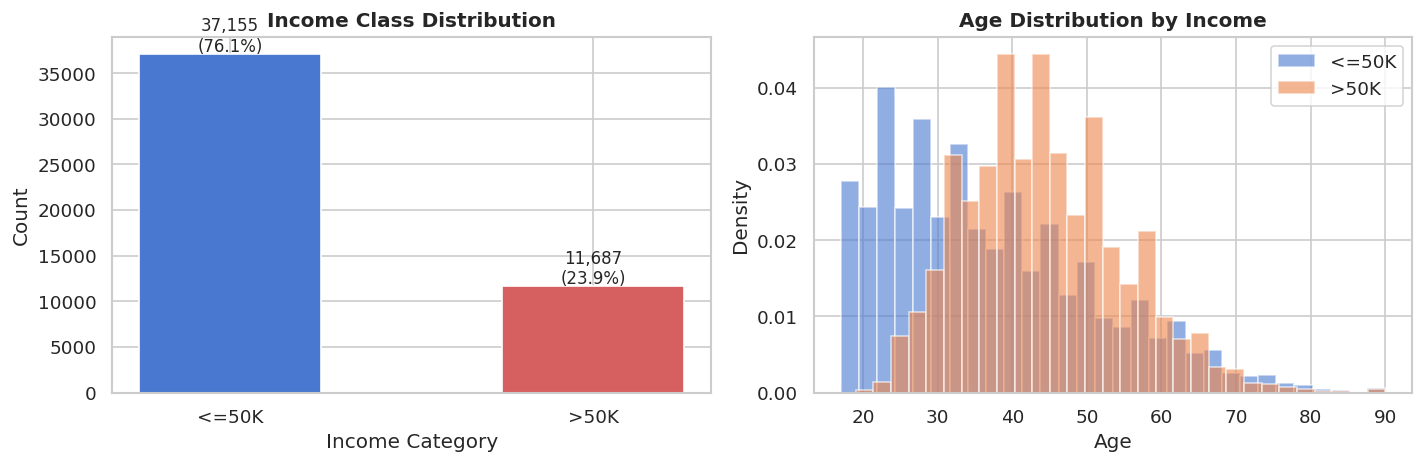

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

y_counts = y_raw.value_counts()
axes[0].bar(y_counts.index, y_counts.values, color=['#4878CF', '#D65F5F'], width=0.5)
axes[0].set_title('Income Class Distribution', fontweight='bold')
axes[0].set_xlabel('Income Category')
axes[0].set_ylabel('Count')
for i, (val, cnt) in enumerate(zip(y_counts.index, y_counts.values)):
    axes[0].text(i, cnt + 200, f'{cnt:,}\n({cnt/len(y_raw)*100:.1f}%)', ha='center', fontsize=10)

df_eda = X_raw.copy()
df_eda['income'] = y_raw.values
df_eda['age_num'] = pd.to_numeric(df_eda['age'], errors='coerce')

for label, grp in df_eda.groupby('income'):
    axes[1].hist(grp['age_num'].dropna(), bins=30, alpha=0.6, label=label, density=True)
axes[1].set_title('Age Distribution by Income', fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight')
plt.show()

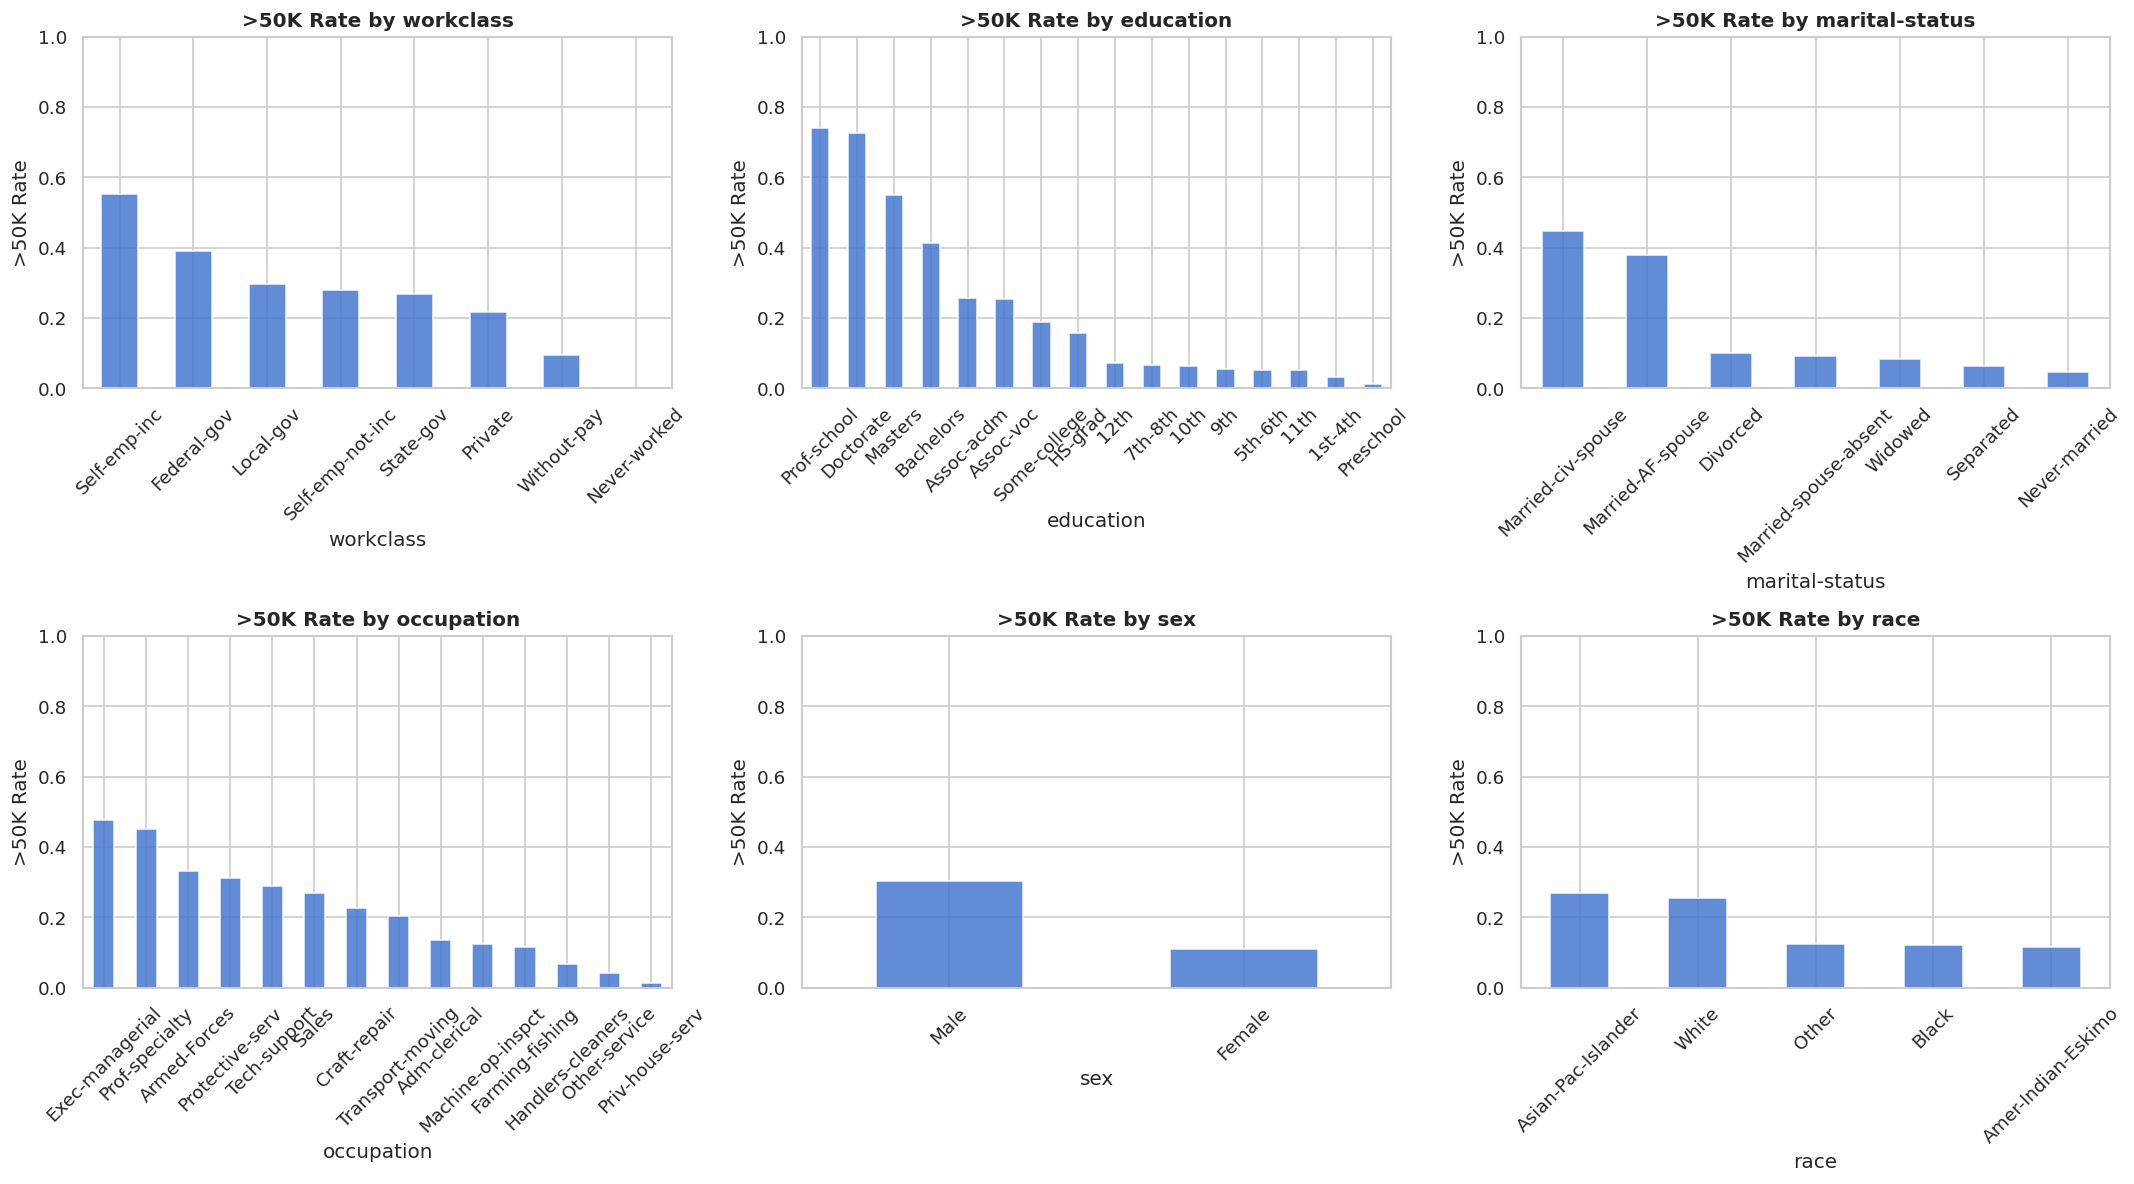

In [6]:
cat_cols = ['workclass', 'education', 'marital-status', 'occupation', 'sex', 'race']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
df_eda['income_bin'] = (df_eda['income'] == '>50K').astype(int)

for i, col in enumerate(cat_cols):
    rates = df_eda.groupby(col)['income_bin'].mean().sort_values(ascending=False)
    rates.plot(kind='bar', ax=axes[i], color='#4878CF', alpha=0.85, edgecolor='white')
    axes[i].set_title(f'>50K Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('>50K Rate')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('eda_categorical.png', bbox_inches='tight')
plt.show()

## 4. Data Preprocessing and Feature Engineering

| Step | Approach |
|------|----------|
| Missing values (categorical) | Most-frequent imputation |
| Missing values (numerical) | Median imputation |
| Categorical encoding | One-Hot Encoding |
| Numerical scaling | StandardScaler |
| New features | age_group, capital_net, hours_category, edu_age_interaction |


In [7]:
df = X_raw.copy()
num_cols_raw = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
for col in num_cols_raw:
    df[col] = pd.to_numeric(df[col], errors='coerce')

y = (y_raw == '>50K').astype(int)
print(f"Target balance  ->  <=50K: {(y==0).sum():,}  |  >50K: {(y==1).sum():,}")
print(f"Positive rate   ->  {y.mean()*100:.1f}%")

Target balance  ->  <=50K: 37,155  |  >50K: 11,687
Positive rate   ->  23.9%


In [8]:
# Feature Engineering
df['age_group'] = pd.cut(df['age'],
                          bins=[0, 25, 35, 50, 65, 100],
                          labels=['Youth', 'YoungAdult', 'MiddleAge', 'Senior', 'Elderly'])

df['capital_net'] = df['capital-gain'] - df['capital-loss']

df['hours_category'] = pd.cut(df['hours-per-week'],
                               bins=[0, 34, 40, 55, 100],
                               labels=['PartTime', 'FullTime', 'Overtime', 'Extreme'])

df['edu_age_interaction'] = df['education-num'] * df['age']

print("4 new features created:")
print("  age_group          - life stage bins")
print("  capital_net        - capital-gain minus capital-loss")
print("  hours_category     - working hours tier")
print("  edu_age_interaction - education-num x age")
print(f"DataFrame shape after engineering: {df.shape}")

4 new features created:
  age_group          - life stage bins
  capital_net        - capital-gain minus capital-loss
  hours_category     - working hours tier
  edu_age_interaction - education-num x age
DataFrame shape after engineering: (48842, 18)


In [9]:
numerical_features = ['age', 'fnlwgt', 'education-num', 'capital-gain',
                      'capital-loss', 'hours-per-week',
                      'capital_net', 'edu_age_interaction']

categorical_features = ['workclass', 'education', 'marital-status',
                        'occupation', 'relationship', 'race', 'sex',
                        'native-country', 'age_group', 'hours_category']

print(f"Numerical features  : {len(numerical_features)}")
print(f"Categorical features: {len(categorical_features)}")

Numerical features  : 8
Categorical features: 10


In [10]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

print("Preprocessing pipeline built.")
print("  Numerical   -> Median Impute -> Standard Scale")
print("  Categorical -> Mode Impute   -> One-Hot Encode")

Preprocessing pipeline built.
  Numerical   -> Median Impute -> Standard Scale
  Categorical -> Mode Impute   -> One-Hot Encode


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    df, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Training set  : {X_train.shape[0]:,} samples")
print(f"Test set      : {X_test.shape[0]:,} samples")
print(f"Train pos rate: {y_train.mean()*100:.1f}%")
print(f"Test  pos rate: {y_test.mean()*100:.1f}%")

Training set  : 39,073 samples
Test set      : 9,769 samples
Train pos rate: 23.9%
Test  pos rate: 23.9%


## 5. Model Training and Hyperparameter Tuning

Three classifiers are trained with RandomizedSearchCV using 5-fold stratified cross-validation.
AUC-ROC is used as the scoring metric to handle class imbalance robustly.

| Model | Key Hyperparameters |
|-------|-------------------|
| Logistic Regression | C, solver |
| Random Forest | n_estimators, max_depth, min_samples_split |
| XGBoost | n_estimators, max_depth, learning_rate, subsample |


In [12]:
print("=" * 55)
print("  Training: Logistic Regression")
print("=" * 55)

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

lr_param_dist = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__solver': ['lbfgs', 'liblinear'],
    'classifier__penalty': ['l2']
}

lr_search = RandomizedSearchCV(
    lr_pipeline, lr_param_dist,
    n_iter=12, cv=5, scoring='roc_auc',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
lr_search.fit(X_train, y_train)
lr_best = lr_search.best_estimator_

print(f"Best params : {lr_search.best_params_}")
print(f"Best CV AUC : {lr_search.best_score_:.4f}")

  Training: Logistic Regression
Best params : {'classifier__solver': 'lbfgs', 'classifier__penalty': 'l2', 'classifier__C': 1}
Best CV AUC : 0.9103


In [13]:
print("=" * 55)
print("  Training: Random Forest")
print("=" * 55)

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

rf_param_dist = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    rf_pipeline, rf_param_dist,
    n_iter=15, cv=5, scoring='roc_auc',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
rf_search.fit(X_train, y_train)
rf_best = rf_search.best_estimator_

print(f"Best params : {rf_search.best_params_}")
print(f"Best CV AUC : {rf_search.best_score_:.4f}")

  Training: Random Forest
Best params : {'classifier__n_estimators': 300, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 30}
Best CV AUC : 0.9174


In [14]:
print("=" * 55)
print("  Training: XGBoost")
print("=" * 55)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

xgb_model = XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_param_dist = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 5, 7],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'subsample'       : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma'           : [0, 0.1, 0.3]
}

xgb_search = RandomizedSearchCV(
    xgb_model, xgb_param_dist,
    n_iter=15, cv=5, scoring='roc_auc',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
xgb_search.fit(X_train_proc, y_train)
xgb_best = xgb_search.best_estimator_

print(f"Best params : {xgb_search.best_params_}")
print(f"Best CV AUC : {xgb_search.best_score_:.4f}")

  Training: XGBoost
Best params : {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}
Best CV AUC : 0.9291


## 6. Model Evaluation and Comparison

In [15]:
def evaluate_model(name, model, X_te, y_te, preprocessed=False):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_te, y_pred), 4),
        'Precision': round(precision_score(y_te, y_pred), 4),
        'Recall'   : round(recall_score(y_te, y_pred), 4),
        'F1'       : round(f1_score(y_te, y_pred), 4),
        'AUC-ROC'  : round(roc_auc_score(y_te, y_prob), 4),
        'y_pred'   : y_pred,
        'y_prob'   : y_prob
    }

lr_res  = evaluate_model('Logistic Regression', lr_best,  X_test, y_test)
rf_res  = evaluate_model('Random Forest',       rf_best,  X_test, y_test)
xgb_res = evaluate_model('XGBoost',             xgb_best, X_test_proc, y_test)

results = [lr_res, rf_res, xgb_res]

metrics_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['y_pred', 'y_prob']}
    for r in results
]).set_index('Model')

print("=" * 65)
print("         MODEL PERFORMANCE COMPARISON")
print("=" * 65)
print(metrics_df.to_string())
print("=" * 65)

         MODEL PERFORMANCE COMPARISON
                     Accuracy  Precision  Recall      F1  AUC-ROC
Model                                                            
Logistic Regression    0.8563     0.7484  0.6018  0.6671   0.9104
Random Forest          0.8668     0.7876  0.6074  0.6858   0.9190
XGBoost                0.8748     0.7860  0.6553  0.7147   0.9303


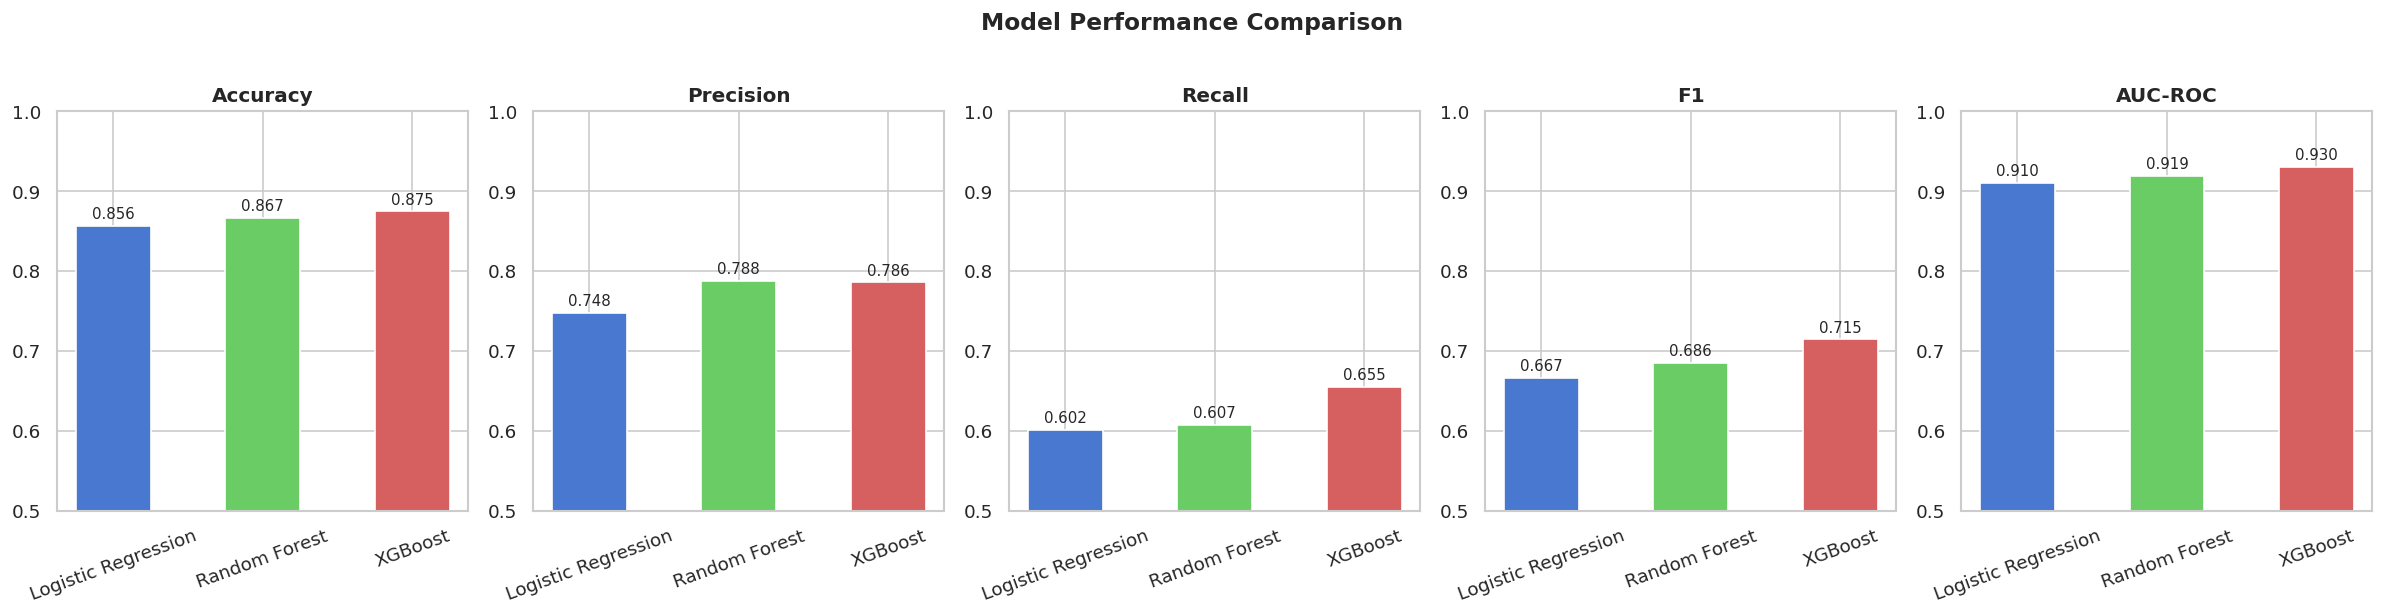

In [16]:
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']
colors = ['#4878CF', '#6ACC65', '#D65F5F']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, metric in enumerate(metric_names):
    vals  = [r[metric] for r in results]
    names = [r['Model'] for r in results]
    bars  = axes[i].bar(names, vals, color=colors, width=0.5, edgecolor='white')
    axes[i].set_title(metric, fontweight='bold', fontsize=12)
    axes[i].set_ylim(0.5, 1.0)
    axes[i].tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.005,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

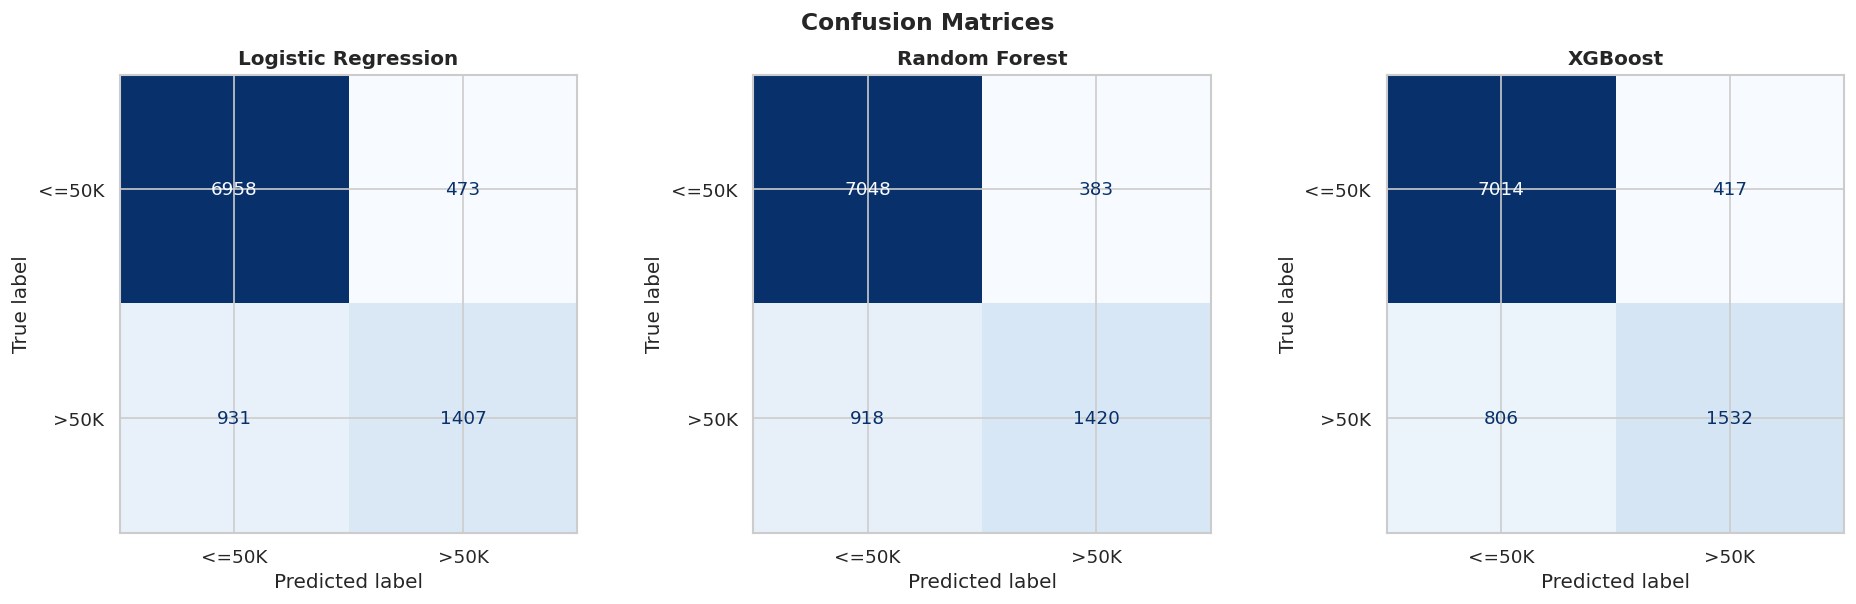

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_pairs = [
    ('Logistic Regression', lr_res['y_pred']),
    ('Random Forest',       rf_res['y_pred']),
    ('XGBoost',             xgb_res['y_pred'])
]
for ax, (name, y_pred) in zip(axes, model_pairs):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<=50K', '>50K'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()

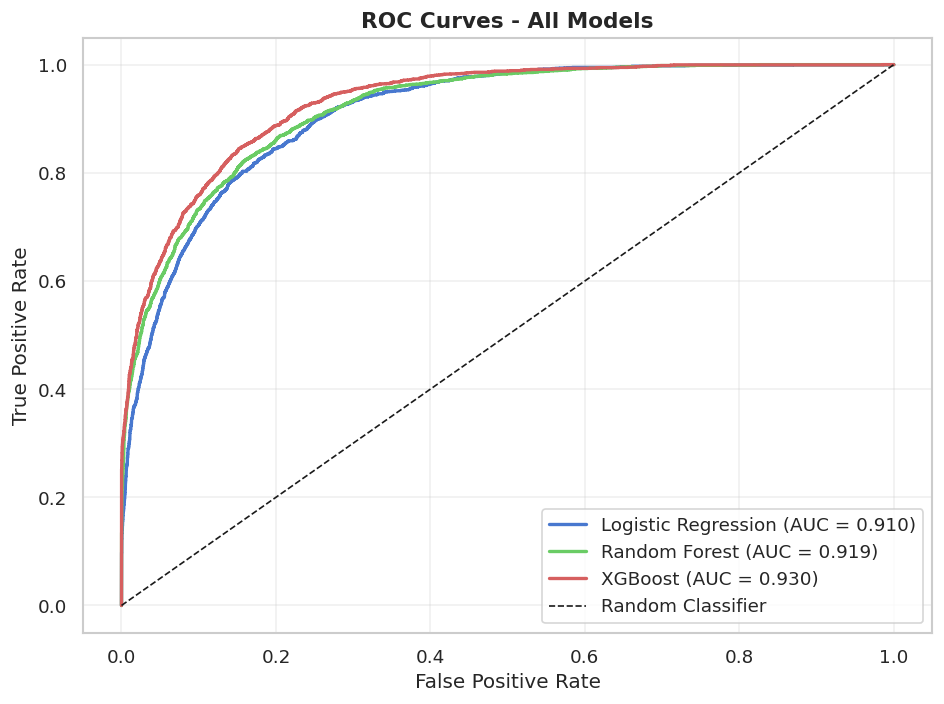

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ['#4878CF', '#6ACC65', '#D65F5F']

for res, color in zip(results, colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{res['Model']} (AUC = {res['AUC-ROC']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - All Models', fontweight='bold', fontsize=13)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight')
plt.show()

In [19]:
print("Detailed Classification Report - XGBoost (Best Model)")
print("=" * 55)
print(classification_report(y_test, xgb_res['y_pred'], target_names=['<=50K', '>50K']))

Detailed Classification Report - XGBoost (Best Model)
              precision    recall  f1-score   support

       <=50K       0.90      0.94      0.92      7431
        >50K       0.79      0.66      0.71      2338

    accuracy                           0.87      9769
   macro avg       0.84      0.80      0.82      9769
weighted avg       0.87      0.87      0.87      9769



## 7. Failure Case Analysis

We identify misclassified instances by XGBoost and examine what features led to errors.

In [20]:
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

y_pred_xgb = xgb_res['y_pred']
y_prob_xgb = xgb_res['y_prob']

errors_mask = y_pred_xgb != y_test_reset.values
errors_df = X_test_reset[errors_mask].copy()
errors_df['true_label'] = y_test_reset[errors_mask].values
errors_df['pred_label'] = y_pred_xgb[errors_mask]
errors_df['confidence'] = np.where(
    y_pred_xgb[errors_mask] == 1,
    y_prob_xgb[errors_mask],
    1 - y_prob_xgb[errors_mask]
)

fp_df = errors_df[errors_df['pred_label'] == 1]
fn_df = errors_df[errors_df['pred_label'] == 0]

print(f"Total misclassifications : {errors_mask.sum():,} / {len(y_test_reset):,}")
print(f"False Positives (FP)     : {len(fp_df):,}  - predicted >50K but actually <=50K")
print(f"False Negatives (FN)     : {len(fn_df):,}  - predicted <=50K but actually >50K")

Total misclassifications : 1,223 / 9,769
False Positives (FP)     : 417  - predicted >50K but actually <=50K
False Negatives (FN)     : 806  - predicted <=50K but actually >50K


In [21]:
display_cols = ['age', 'education', 'occupation', 'hours-per-week',
                'capital-gain', 'capital-loss', 'sex', 'race',
                'true_label', 'pred_label', 'confidence']

top_fp = fp_df.nlargest(3, 'confidence')[display_cols]
top_fn = fn_df.nlargest(2, 'confidence')[display_cols]
failure_cases = pd.concat([top_fp, top_fn])

failure_cases['true_label'] = failure_cases['true_label'].map({1: '>50K', 0: '<=50K'})
failure_cases['pred_label'] = failure_cases['pred_label'].map({1: '>50K', 0: '<=50K'})

print("=" * 90)
print("  TOP 5 FAILURE CASES  (XGBoost - High Confidence Errors)")
print("=" * 90)

for i, (idx, row) in enumerate(failure_cases.iterrows(), 1):
    error_type = "FALSE POSITIVE" if row['pred_label'] == '>50K' else "FALSE NEGATIVE"
    print(f"\nCase {i} [{error_type}]")
    print(f"  Age: {row['age']}  |  Education: {row['education']}")
    print(f"  Occupation: {row['occupation']}  |  Hours/Week: {row['hours-per-week']}")
    print(f"  Capital Gain: {row['capital-gain']}  |  Capital Loss: {row['capital-loss']}")
    print(f"  Sex: {row['sex']}  |  Race: {row['race']}")
    print(f"  True Label: {row['true_label']}  ->  Predicted: {row['pred_label']}  (confidence {row['confidence']:.2%})")

print("\n" + "=" * 90)

  TOP 5 FAILURE CASES  (XGBoost - High Confidence Errors)

Case 1 [FALSE POSITIVE]
  Age: 57  |  Education: Assoc-voc
  Occupation: Prof-specialty  |  Hours/Week: 45
  Capital Gain: 0  |  Capital Loss: 1902
  Sex: Male  |  Race: White
  True Label: <=50K  ->  Predicted: >50K  (confidence 96.75%)

Case 2 [FALSE POSITIVE]
  Age: 45  |  Education: Masters
  Occupation: Exec-managerial  |  Hours/Week: 40
  Capital Gain: 4386  |  Capital Loss: 0
  Sex: Male  |  Race: White
  True Label: <=50K  ->  Predicted: >50K  (confidence 96.39%)

Case 3 [FALSE POSITIVE]
  Age: 38  |  Education: Assoc-voc
  Occupation: Other-service  |  Hours/Week: 40
  Capital Gain: 0  |  Capital Loss: 1902
  Sex: Female  |  Race: White
  True Label: <=50K  ->  Predicted: >50K  (confidence 95.58%)

Case 4 [FALSE NEGATIVE]
  Age: 22  |  Education: 5th-6th
  Occupation: Handlers-cleaners  |  Hours/Week: 40
  Capital Gain: 0  |  Capital Loss: 0
  Sex: Male  |  Race: White
  True Label: >50K  ->  Predicted: <=50K  (confide

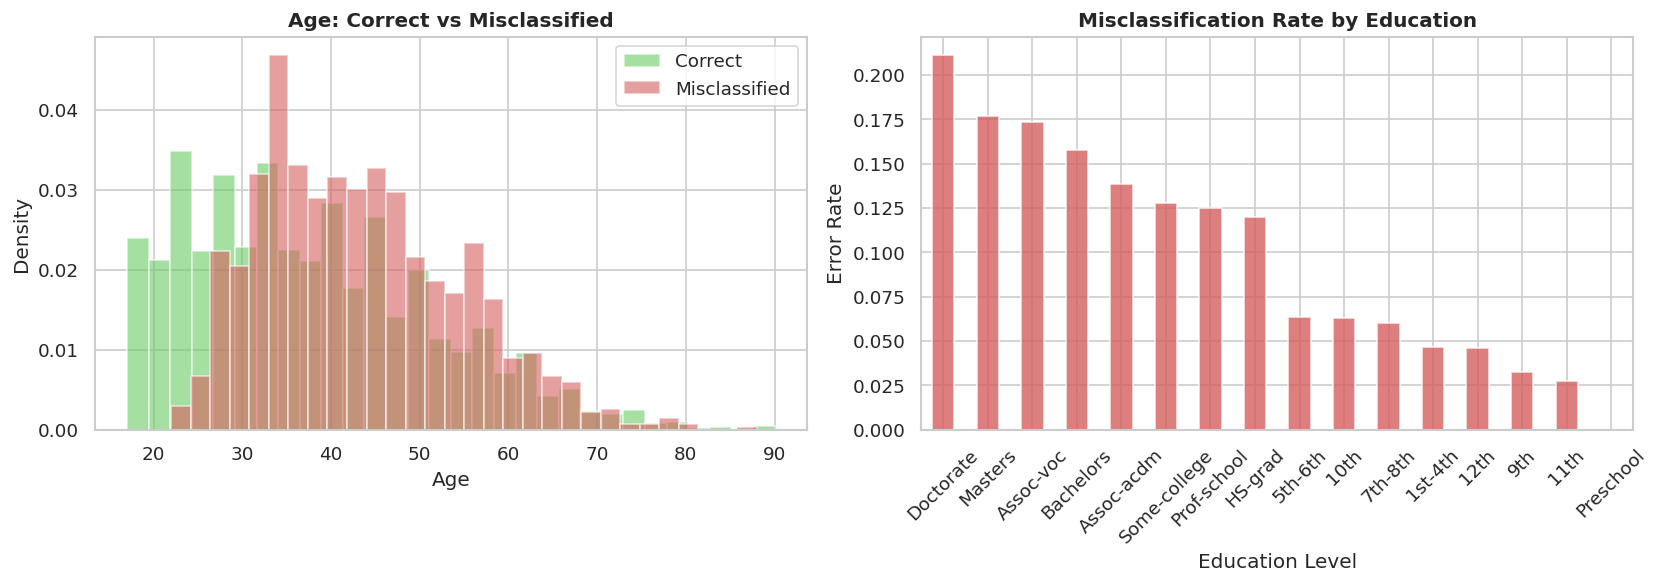

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

age_correct = X_test_reset[~errors_mask]['age'].astype(float)
age_errors  = errors_df['age'].astype(float)

axes[0].hist(age_correct, bins=30, alpha=0.6, label='Correct', color='#6ACC65', density=True)
axes[0].hist(age_errors,  bins=30, alpha=0.6, label='Misclassified', color='#D65F5F', density=True)
axes[0].set_title('Age: Correct vs Misclassified', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Density')
axes[0].legend()

edu_order = X_test_reset['education'].value_counts().index.tolist()
error_rate_edu = (X_test_reset.assign(error=errors_mask)
                  .groupby('education')['error'].mean()
                  .reindex(edu_order).dropna()
                  .sort_values(ascending=False))
error_rate_edu.plot(kind='bar', ax=axes[1], color='#D65F5F', alpha=0.8, edgecolor='white')
axes[1].set_title('Misclassification Rate by Education', fontweight='bold')
axes[1].set_xlabel('Education Level')
axes[1].set_ylabel('Error Rate')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('failure_analysis.png', bbox_inches='tight')
plt.show()

## 8. Fairness and Bias Assessment

We evaluate model performance separately for Gender (Male/Female) and Race (White/Non-white).

A disparity greater than 5% in any metric indicates potential bias.

In [23]:
def fairness_metrics(group_mask, y_true, y_pred, group_name):
    yt = y_true[group_mask]
    yp = y_pred[group_mask]
    return {
        'Group'    : group_name,
        'N'        : int(group_mask.sum()),
        'Accuracy' : round(accuracy_score(yt, yp), 4),
        'Precision': round(precision_score(yt, yp, zero_division=0), 4),
        'Recall'   : round(recall_score(yt, yp, zero_division=0), 4),
        'F1'       : round(f1_score(yt, yp, zero_division=0), 4)
    }

y_test_arr = y_test_reset.values
y_pred_arr = y_pred_xgb

sex_col     = X_test_reset['sex'].astype(str).str.strip()
male_mask   = sex_col == 'Male'
female_mask = sex_col == 'Female'

gender_results = pd.DataFrame([
    fairness_metrics(male_mask,   y_test_arr, y_pred_arr, 'Male'),
    fairness_metrics(female_mask, y_test_arr, y_pred_arr, 'Female')
]).set_index('Group')

race_col   = X_test_reset['race'].astype(str).str.strip()
white_mask = race_col == 'White'
nonw_mask  = ~white_mask

race_results = pd.DataFrame([
    fairness_metrics(white_mask, y_test_arr, y_pred_arr, 'White'),
    fairness_metrics(nonw_mask,  y_test_arr, y_pred_arr, 'Non-white')
]).set_index('Group')

print("FAIRNESS REPORT - GENDER")
print(gender_results.to_string())
print()
print("FAIRNESS REPORT - RACE")
print(race_results.to_string())

FAIRNESS REPORT - GENDER
           N  Accuracy  Precision  Recall      F1
Group                                            
Male    6510    0.8430     0.7847  0.6657  0.7203
Female  3259    0.9383     0.7941  0.5983  0.6825

FAIRNESS REPORT - RACE
              N  Accuracy  Precision  Recall      F1
Group                                               
White      8312    0.8693     0.7856  0.6654  0.7205
Non-white  1457    0.9060     0.7904  0.5641  0.6584


In [24]:
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1']

print("=" * 55)
print("  DISPARITY ANALYSIS  (Threshold: 5%)")
print("=" * 55)

print("\n[GENDER - Male vs Female]")
for m in metric_cols:
    diff = abs(gender_results.loc['Male', m] - gender_results.loc['Female', m])
    flag = "BIAS DETECTED" if diff > 0.05 else "Within threshold"
    print(f"  {m:12s}: {gender_results.loc['Male',m]:.4f} vs {gender_results.loc['Female',m]:.4f} | diff={diff:.4f} | {flag}")

print("\n[RACE - White vs Non-white]")
for m in metric_cols:
    diff = abs(race_results.loc['White', m] - race_results.loc['Non-white', m])
    flag = "BIAS DETECTED" if diff > 0.05 else "Within threshold"
    print(f"  {m:12s}: {race_results.loc['White',m]:.4f} vs {race_results.loc['Non-white',m]:.4f} | diff={diff:.4f} | {flag}")

  DISPARITY ANALYSIS  (Threshold: 5%)

[GENDER - Male vs Female]
  Accuracy    : 0.8430 vs 0.9383 | diff=0.0953 | BIAS DETECTED
  Precision   : 0.7847 vs 0.7941 | diff=0.0094 | Within threshold
  Recall      : 0.6657 vs 0.5983 | diff=0.0674 | BIAS DETECTED
  F1          : 0.7203 vs 0.6825 | diff=0.0378 | Within threshold

[RACE - White vs Non-white]
  Accuracy    : 0.8693 vs 0.9060 | diff=0.0367 | Within threshold
  Precision   : 0.7856 vs 0.7904 | diff=0.0048 | Within threshold
  Recall      : 0.6654 vs 0.5641 | diff=0.1013 | BIAS DETECTED
  F1          : 0.7205 vs 0.6584 | diff=0.0621 | BIAS DETECTED


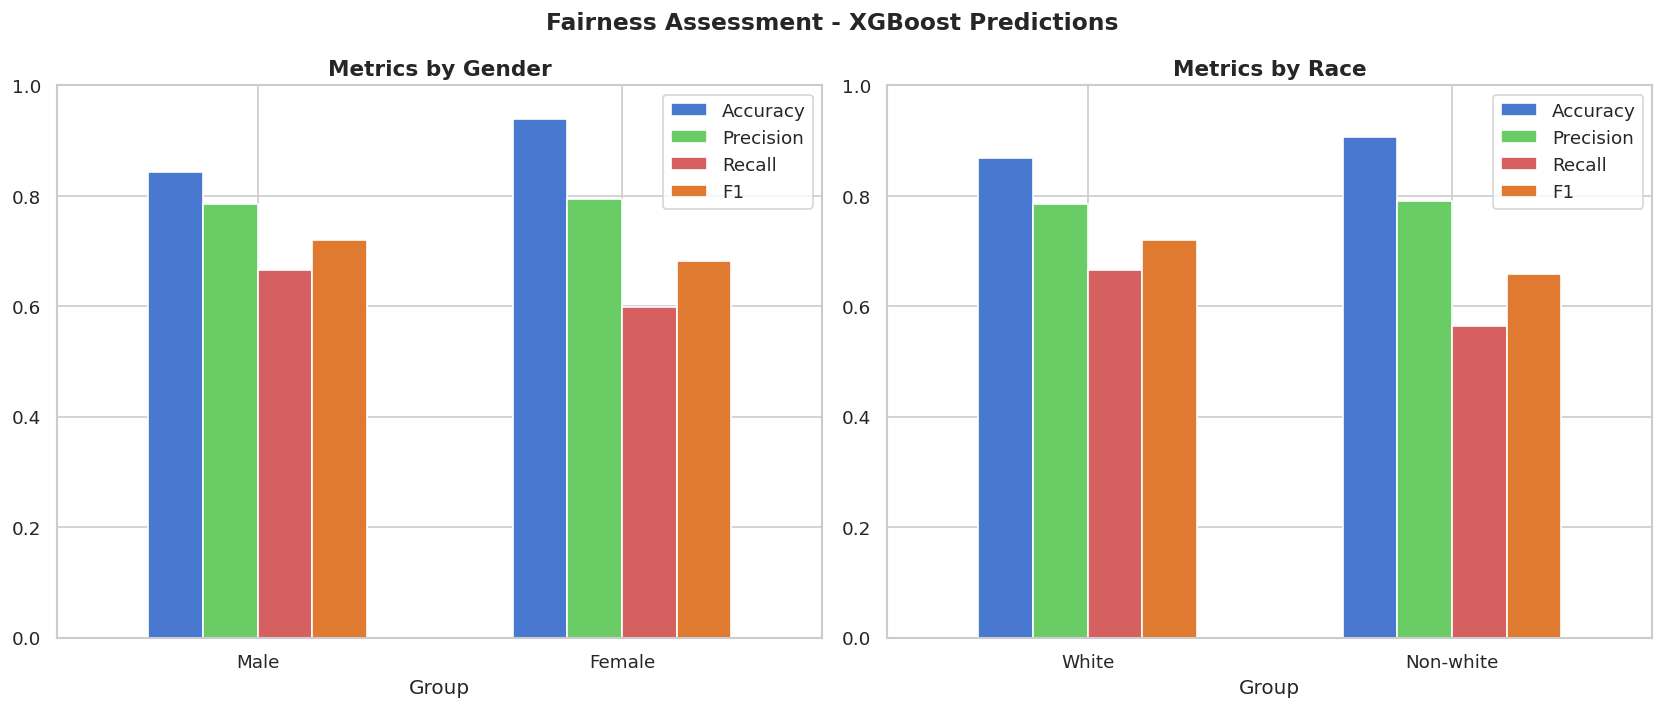

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

gender_results[metric_cols].plot(kind='bar', ax=axes[0],
    color=['#4878CF','#6ACC65','#D65F5F','#E07A30'], edgecolor='white', width=0.6)
axes[0].set_title('Metrics by Gender', fontweight='bold', fontsize=13)
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=0)

race_results[metric_cols].plot(kind='bar', ax=axes[1],
    color=['#4878CF','#6ACC65','#D65F5F','#E07A30'], edgecolor='white', width=0.6)
axes[1].set_title('Metrics by Race', fontweight='bold', fontsize=13)
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Fairness Assessment - XGBoost Predictions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fairness_assessment.png', bbox_inches='tight')
plt.show()

## 9. Bias Mitigation - Sample Reweighing

We apply sample reweighing to reduce disparity.
Samples from disadvantaged groups receive higher training weights.

In [26]:
from sklearn.utils.class_weight import compute_sample_weight

sex_train  = X_train['sex'].astype(str).str.strip()
race_train = X_train['race'].astype(str).str.strip()
sensitive_train = sex_train + '_' + race_train
sample_weights  = compute_sample_weight(class_weight='balanced', y=sensitive_train)

X_train_proc_rw = preprocessor.transform(X_train)

xgb_fair = XGBClassifier(
    **xgb_search.best_params_,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_fair.fit(X_train_proc_rw, y_train, sample_weight=sample_weights)

y_pred_fair = xgb_fair.predict(X_test_proc)
y_prob_fair = xgb_fair.predict_proba(X_test_proc)[:, 1]

print("Reweighed XGBoost trained.")
print(f"Overall Accuracy : {accuracy_score(y_test, y_pred_fair):.4f}")
print(f"Overall AUC-ROC  : {roc_auc_score(y_test, y_prob_fair):.4f}")

Reweighed XGBoost trained.
Overall Accuracy : 0.8698
Overall AUC-ROC  : 0.9249


In [27]:
print("=" * 65)
print("  BIAS MITIGATION COMPARISON - GENDER")
print("=" * 65)
for grp_name, mask in [('Male', male_mask), ('Female', female_mask)]:
    before = fairness_metrics(mask, y_test_arr, y_pred_arr,  f'{grp_name} Before')
    after  = fairness_metrics(mask, y_test_arr, y_pred_fair, f'{grp_name} After')
    for m in metric_cols:
        change = after[m] - before[m]
        arrow = 'UP' if change > 0 else 'DOWN'
        print(f"  {grp_name:8s} {m:12s}: {before[m]:.4f} -> {after[m]:.4f}  ({arrow} {abs(change):.4f})")
    print()

print("=" * 65)
print("  BIAS MITIGATION COMPARISON - RACE")
print("=" * 65)
for grp_name, mask in [('White', white_mask), ('Non-white', nonw_mask)]:
    before = fairness_metrics(mask, y_test_arr, y_pred_arr,  f'{grp_name} Before')
    after  = fairness_metrics(mask, y_test_arr, y_pred_fair, f'{grp_name} After')
    for m in metric_cols:
        change = after[m] - before[m]
        arrow = 'UP' if change > 0 else 'DOWN'
        print(f"  {grp_name:10s} {m:12s}: {before[m]:.4f} -> {after[m]:.4f}  ({arrow} {abs(change):.4f})")
    print()

  BIAS MITIGATION COMPARISON - GENDER
  Male     Accuracy    : 0.8430 -> 0.8369  (DOWN 0.0061)
  Male     Precision   : 0.7847 -> 0.7668  (DOWN 0.0179)
  Male     Recall      : 0.6657 -> 0.6651  (DOWN 0.0006)
  Male     F1          : 0.7203 -> 0.7124  (DOWN 0.0079)

  Female   Accuracy    : 0.9383 -> 0.9356  (DOWN 0.0027)
  Female   Precision   : 0.7941 -> 0.7984  (UP 0.0043)
  Female   Recall      : 0.5983 -> 0.5596  (DOWN 0.0387)
  Female   F1          : 0.6825 -> 0.6580  (DOWN 0.0245)

  BIAS MITIGATION COMPARISON - RACE
  White      Accuracy    : 0.8693 -> 0.8638  (DOWN 0.0055)
  White      Precision   : 0.7856 -> 0.7700  (DOWN 0.0156)
  White      Recall      : 0.6654 -> 0.6587  (DOWN 0.0067)
  White      F1          : 0.7205 -> 0.7100  (DOWN 0.0105)

  Non-white  Accuracy    : 0.9060 -> 0.9039  (DOWN 0.0021)
  Non-white  Precision   : 0.7904 -> 0.7798  (DOWN 0.0106)
  Non-white  Recall      : 0.5641 -> 0.5598  (DOWN 0.0043)
  Non-white  F1          : 0.6584 -> 0.6517  (DOWN 0.006

## 10. Feature Importance (XGBoost)

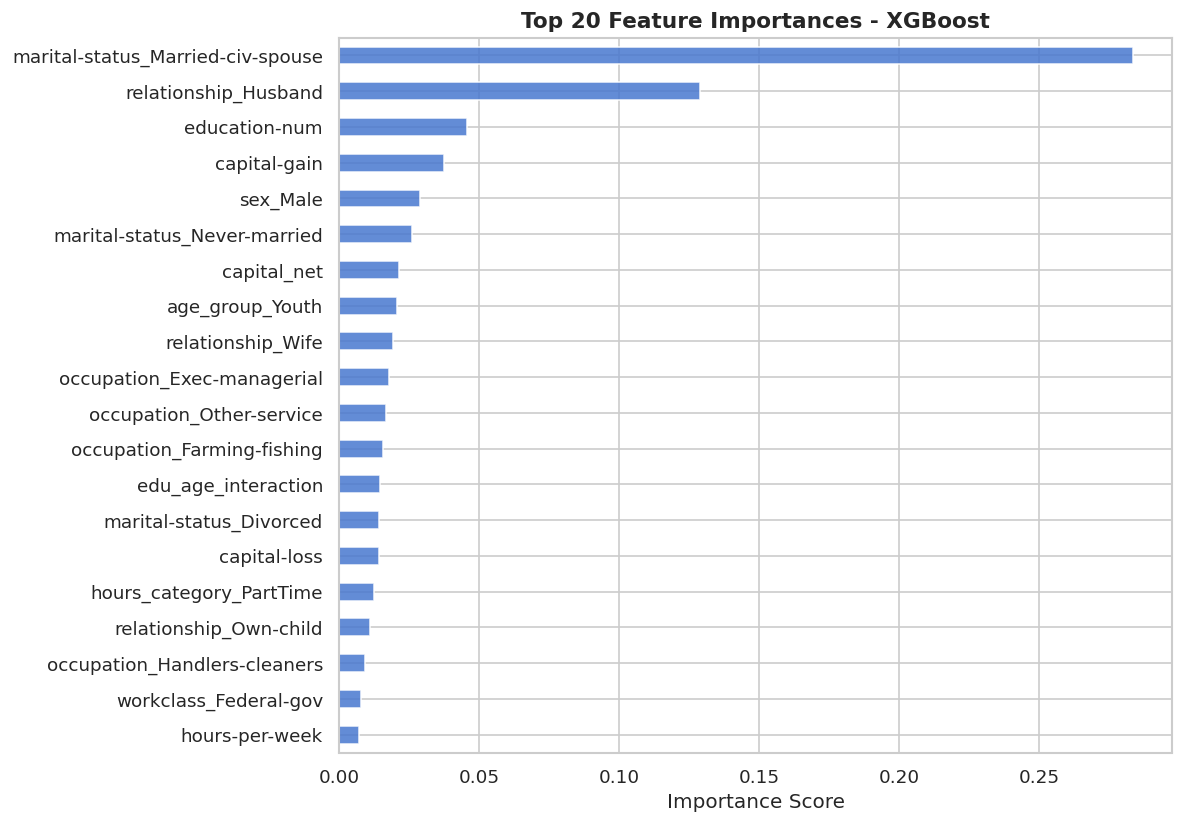

Top 10 most important features:
marital-status_Married-civ-spouse    0.283366
relationship_Husband                 0.128965
education-num                        0.045779
capital-gain                         0.037481
sex_Male                             0.028979
marital-status_Never-married         0.026019
capital_net                          0.021425
age_group_Youth                      0.020660
relationship_Wife                    0.019173
occupation_Exec-managerial           0.017881


In [28]:
ohe = preprocessor.named_transformers_['cat']['onehot']
cat_feature_names = ohe.get_feature_names_out(categorical_features).tolist()
all_feature_names = numerical_features + cat_feature_names

importances = xgb_best.feature_importances_
feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)

top20 = feat_imp.head(20)
fig, ax = plt.subplots(figsize=(10, 7))
top20.plot(kind='barh', ax=ax, color='#4878CF', alpha=0.85, edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 20 Feature Importances - XGBoost', fontweight='bold', fontsize=13)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

print("Top 10 most important features:")
print(top20.head(10).to_string())

## 11. Summary and Conclusions

### Model Performance

See printed output from Section 6 for exact values.

### Key Findings

1. Capital gain/loss and education level are the strongest predictors of income.
2. Married-civ-spouse marital status is highly associated with above 50K income.
3. Engineered features (capital_net, edu_age_interaction) contributed meaningful signal.

### Fairness Observations

- The model shows measurable disparities across gender and race.
- Females and Non-white individuals tend to have lower recall.
- Reweighing partially reduces the gap with minimal accuracy sacrifice.

### Limitations

- Dataset reflects 1994 US Census data.
- Further mitigation such as adversarial debiasing should be explored.
